In [23]:
# ===== IMPORT LIBRARIES =====
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_ta as ta

# Thư viện ARIMAX và time series
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Thư viện HMM cho phát hiện regime
from hmmlearn import hmm

# Thư viện đánh giá mô hình
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    f1_score, precision_score, recall_score, mean_squared_error, mean_absolute_error
)
from sklearn.preprocessing import StandardScaler, RobustScaler

# Thư viện visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tiện ích
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [24]:
tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

# List để chứa dữ liệu tạm
all_data = []

for ticker in tickers:

    df = yf.Ticker(ticker).history(period="max", auto_adjust=True)
    df.drop(["Dividends", "Stock Splits"], axis=1, inplace=True)

    df = df.loc["1990-01-01":].copy()
    
    if len(df) > 0:
        # Định danh mã cổ phiếu
        df['Symbol'] = ticker 
        
        # Reset index để đưa Date vào làm một cột
        df = df.reset_index()
        
        df['Returns'] = df['Close'].pct_change()
        
        df = df.dropna()
        
        all_data.append(df)

# 2. Gộp tất cả lại thành một bảng dài (Long Format)
final_df = pd.concat(all_data, ignore_index=True)

# Sắp xếp lại cho đẹp: Theo Mã -> Theo Ngày
final_df = final_df.sort_values(by=['Symbol', 'Date'])

final_df

,Date,Open,High,Low,Close,Volume,Capital Gains,Symbol,Returns
27451,2004-11-19 00:00:00-05:00,44.490002,44.919998,44.470001,44.779999,11655300,0.0,GLD,0.009013
27452,2004-11-22 00:00:00-05:00,44.750000,44.970001,44.740002,44.950001,11996000,0.0,GLD,0.003796
27453,2004-11-23 00:00:00-05:00,44.880001,44.919998,44.720001,44.750000,3169200,0.0,GLD,-0.004449
27454,2004-11-24 00:00:00-05:00,44.930000,45.049999,44.790001,45.049999,6105100,0.0,GLD,0.006704
27455,2004-11-26 00:00:00-05:00,45.250000,45.599998,45.060001,45.290001,3097700,0.0,GLD,0.005327
...,...,...,...,...,...,...,...,...,...
57755,2026-01-28 00:00:00-05:00,137.690002,138.009995,136.669998,137.580002,15637300,NaN,XOM,0.005481
57756,2026-01-29 00:00:00-05:00,140.320007,142.339996,139.110001,140.509995,35760600,NaN,XOM,0.021297
57757,2026-01-30 00:00:00-05:00,138.740005,142.210007,137.830002,141.399994,29657700,NaN,XOM,0.006334
57758,2026-02-02 00:00:00-05:00,139.830002,140.320007,138.059998,138.399994,27735600,NaN,XOM,-0.021216


## Step 1: Hidden Markov Model - Regime Detection

In [25]:
split_date = '2016-01-01'

train_mask = final_df['Date'] < split_date
test_mask = final_df['Date'] >= split_date

train_data = final_df[train_mask].copy()
test_data = final_df[test_mask].copy()

print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()} ({len(train_data)} samples)")
print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()} ({len(test_data)} samples)")

print("\n" + "="*60)
print("STANDARDIZING RETURNS BY TICKER (Z-SCORE)")
print("="*60)

# Standardize returns for each ticker separately
for ticker in tickers:
    # Train data
    ticker_train_mask = train_data['Symbol'] == ticker
    train_returns = train_data.loc[ticker_train_mask, 'Returns']
    train_mean = train_returns.mean()
    train_std = train_returns.std()
    
    print(f"{ticker} - Train: mean={train_mean:.6f}, std={train_std:.6f}")
    
    # Standardize train
    train_data.loc[ticker_train_mask, 'Returns_Standardized'] = (train_returns - train_mean) / train_std
    
    # Standardize test using TRAIN 
    ticker_test_mask = test_data['Symbol'] == ticker
    test_returns = test_data.loc[ticker_test_mask, 'Returns']
    test_data.loc[ticker_test_mask, 'Returns_Standardized'] = (test_returns - train_mean) / train_std

print("\n" + "="*60)
print("FITTING HMM ON STANDARDIZED RETURNS")
print("="*60)

# Use standardized returns for HMM
returns_train = train_data['Returns_Standardized'].values.reshape(-1, 1)

n_regimes = 3
model_hmm = hmm.GaussianHMM(
    n_components=n_regimes,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

print("\nFitting HMM on TRAIN data (standardized returns, all 6 tickers)...")
model_hmm.fit(returns_train)

train_data['Regime'] = model_hmm.predict(returns_train)
train_regime_probs = model_hmm.predict_proba(returns_train)
for i in range(n_regimes):
    train_data[f'Regime_Prob_{i}'] = train_regime_probs[:, i]

returns_test = test_data['Returns_Standardized'].values.reshape(-1, 1)
test_data['Regime'] = model_hmm.predict(returns_test)
test_regime_probs = model_hmm.predict_proba(returns_test)
for i in range(n_regimes):
    test_data[f'Regime_Prob_{i}'] = test_regime_probs[:, i]

combined_data = pd.concat([train_data, test_data])

print("\n" + "="*60)
print("REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)")
print("="*60)
for i in range(n_regimes):
    regime_returns = train_data[train_data['Regime'] == i]['Returns_Standardized']
    print(f"\nRegime {i}:")
    print(f"  Mean Standardized Return: {regime_returns.mean():.4f}")
    print(f"  Std Standardized Return: {regime_returns.std():.4f}")
    print(f"  Count: {len(regime_returns)} days ({len(regime_returns)/len(train_data)*100:.1f}%)")

# Check regime distribution by ticker
print("\n" + "="*60)
print("REGIME DISTRIBUTION BY TICKER (TRAIN)")
print("="*60)
for ticker in tickers:
    ticker_data = train_data[train_data['Symbol'] == ticker]
    regime_dist = ticker_data['Regime'].value_counts(normalize=True).sort_index() * 100
    print(f"\n{ticker}:")
    for regime_id in range(n_regimes):
        pct = regime_dist.get(regime_id, 0)
        print(f"  Regime {regime_id}: {pct:.1f}%")

print("\n" + "="*60)
print("TRANSITION MATRIX")
print("="*60)
print(pd.DataFrame(model_hmm.transmat_,
                   columns=[f'To Regime {i}' for i in range(n_regimes)],
                   index=[f'From Regime {i}' for i in range(n_regimes)]))

print("\n" + "="*60)
print("REGIME DISTRIBUTION IN TEST DATA")
print("="*60)
for i in range(n_regimes):
    test_regime_count = (test_data['Regime'] == i).sum()
    print(f"Regime {i}: {test_regime_count} days ({test_regime_count/len(test_data)*100:.1f}%)")

combined_data[['Date', 'Symbol', 'Returns', 'Returns_Standardized', 'Regime', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2']].head(10)

Train period: 1990-01-03 00:00:00-05:00 to 2015-12-31 00:00:00-05:00 (46858 samples)
Test period: 2016-01-04 00:00:00-05:00 to 2026-02-03 00:00:00-05:00 (25360 samples)

STANDARDIZING RETURNS BY TICKER (Z-SCORE)
SPY - Train: mean=0.000411, std=0.011905
QQQ - Train: mean=0.000380, std=0.018571
IWM - Train: mean=0.000402, std=0.015456
TLT - Train: mean=0.000311, std=0.008763
GLD - Train: mean=0.000374, std=0.012515
NVDA - Train: mean=0.001542, std=0.040739
JPM - Train: mean=0.000725, std=0.024801
XOM - Train: mean=0.000507, std=0.014824
JNJ - Train: mean=0.000582, std=0.013742
VNQ - Train: mean=0.000581, std=0.021472

FITTING HMM ON STANDARDIZED RETURNS

Fitting HMM on TRAIN data (standardized returns, all 6 tickers)...

REGIME CHARACTERISTICS (TRAIN - STANDARDIZED RETURNS)

Regime 0:
  Mean Standardized Return: -0.0203
  Std Standardized Return: 2.2686
  Count: 3821 days (8.2%)

Regime 1:
  Mean Standardized Return: -0.0089
  Std Standardized Return: 0.9682
  Count: 23936 days (51.1%)



,Date,Symbol,Returns,Returns_Standardized,Regime,Regime_Prob_0,Regime_Prob_1,Regime_Prob_2
27451,2004-11-19 00:00:00-05:00,GLD,0.009013,0.690320,2,3.642115e-161,3.373252e-102,1.000000
27452,2004-11-22 00:00:00-05:00,GLD,0.003796,0.273473,2,5.306516e-08,1.060208e-02,0.989398
27453,2004-11-23 00:00:00-05:00,GLD,-0.004449,-0.385423,2,3.313275e-06,2.931159e-02,0.970685
27454,2004-11-24 00:00:00-05:00,GLD,0.006704,0.505804,2,1.102473e-05,5.722404e-02,0.942765
27455,2004-11-26 00:00:00-05:00,GLD,0.005327,0.395817,2,2.314051e-05,9.598020e-02,0.903997
27456,2004-11-29 00:00:00-05:00,GLD,0.002429,0.164194,2,4.240310e-05,1.582973e-01,0.841660
27457,2004-11-30 00:00:00-05:00,GLD,-0.006167,-0.522708,2,8.481009e-05,2.779613e-01,0.721954
27458,2004-12-01 00:00:00-05:00,GLD,0.005762,0.430577,2,1.762315e-04,4.247362e-01,0.575088
27459,2004-12-02 00:00:00-05:00,GLD,-0.009476,-0.787048,2,3.798419e-04,6.514239e-01,0.348196
27460,2004-12-03 00:00:00-05:00,GLD,0.014460,1.125609,2,7.586221e-04,8.105391e-01,0.188702


Plotting regimes for all tickers...


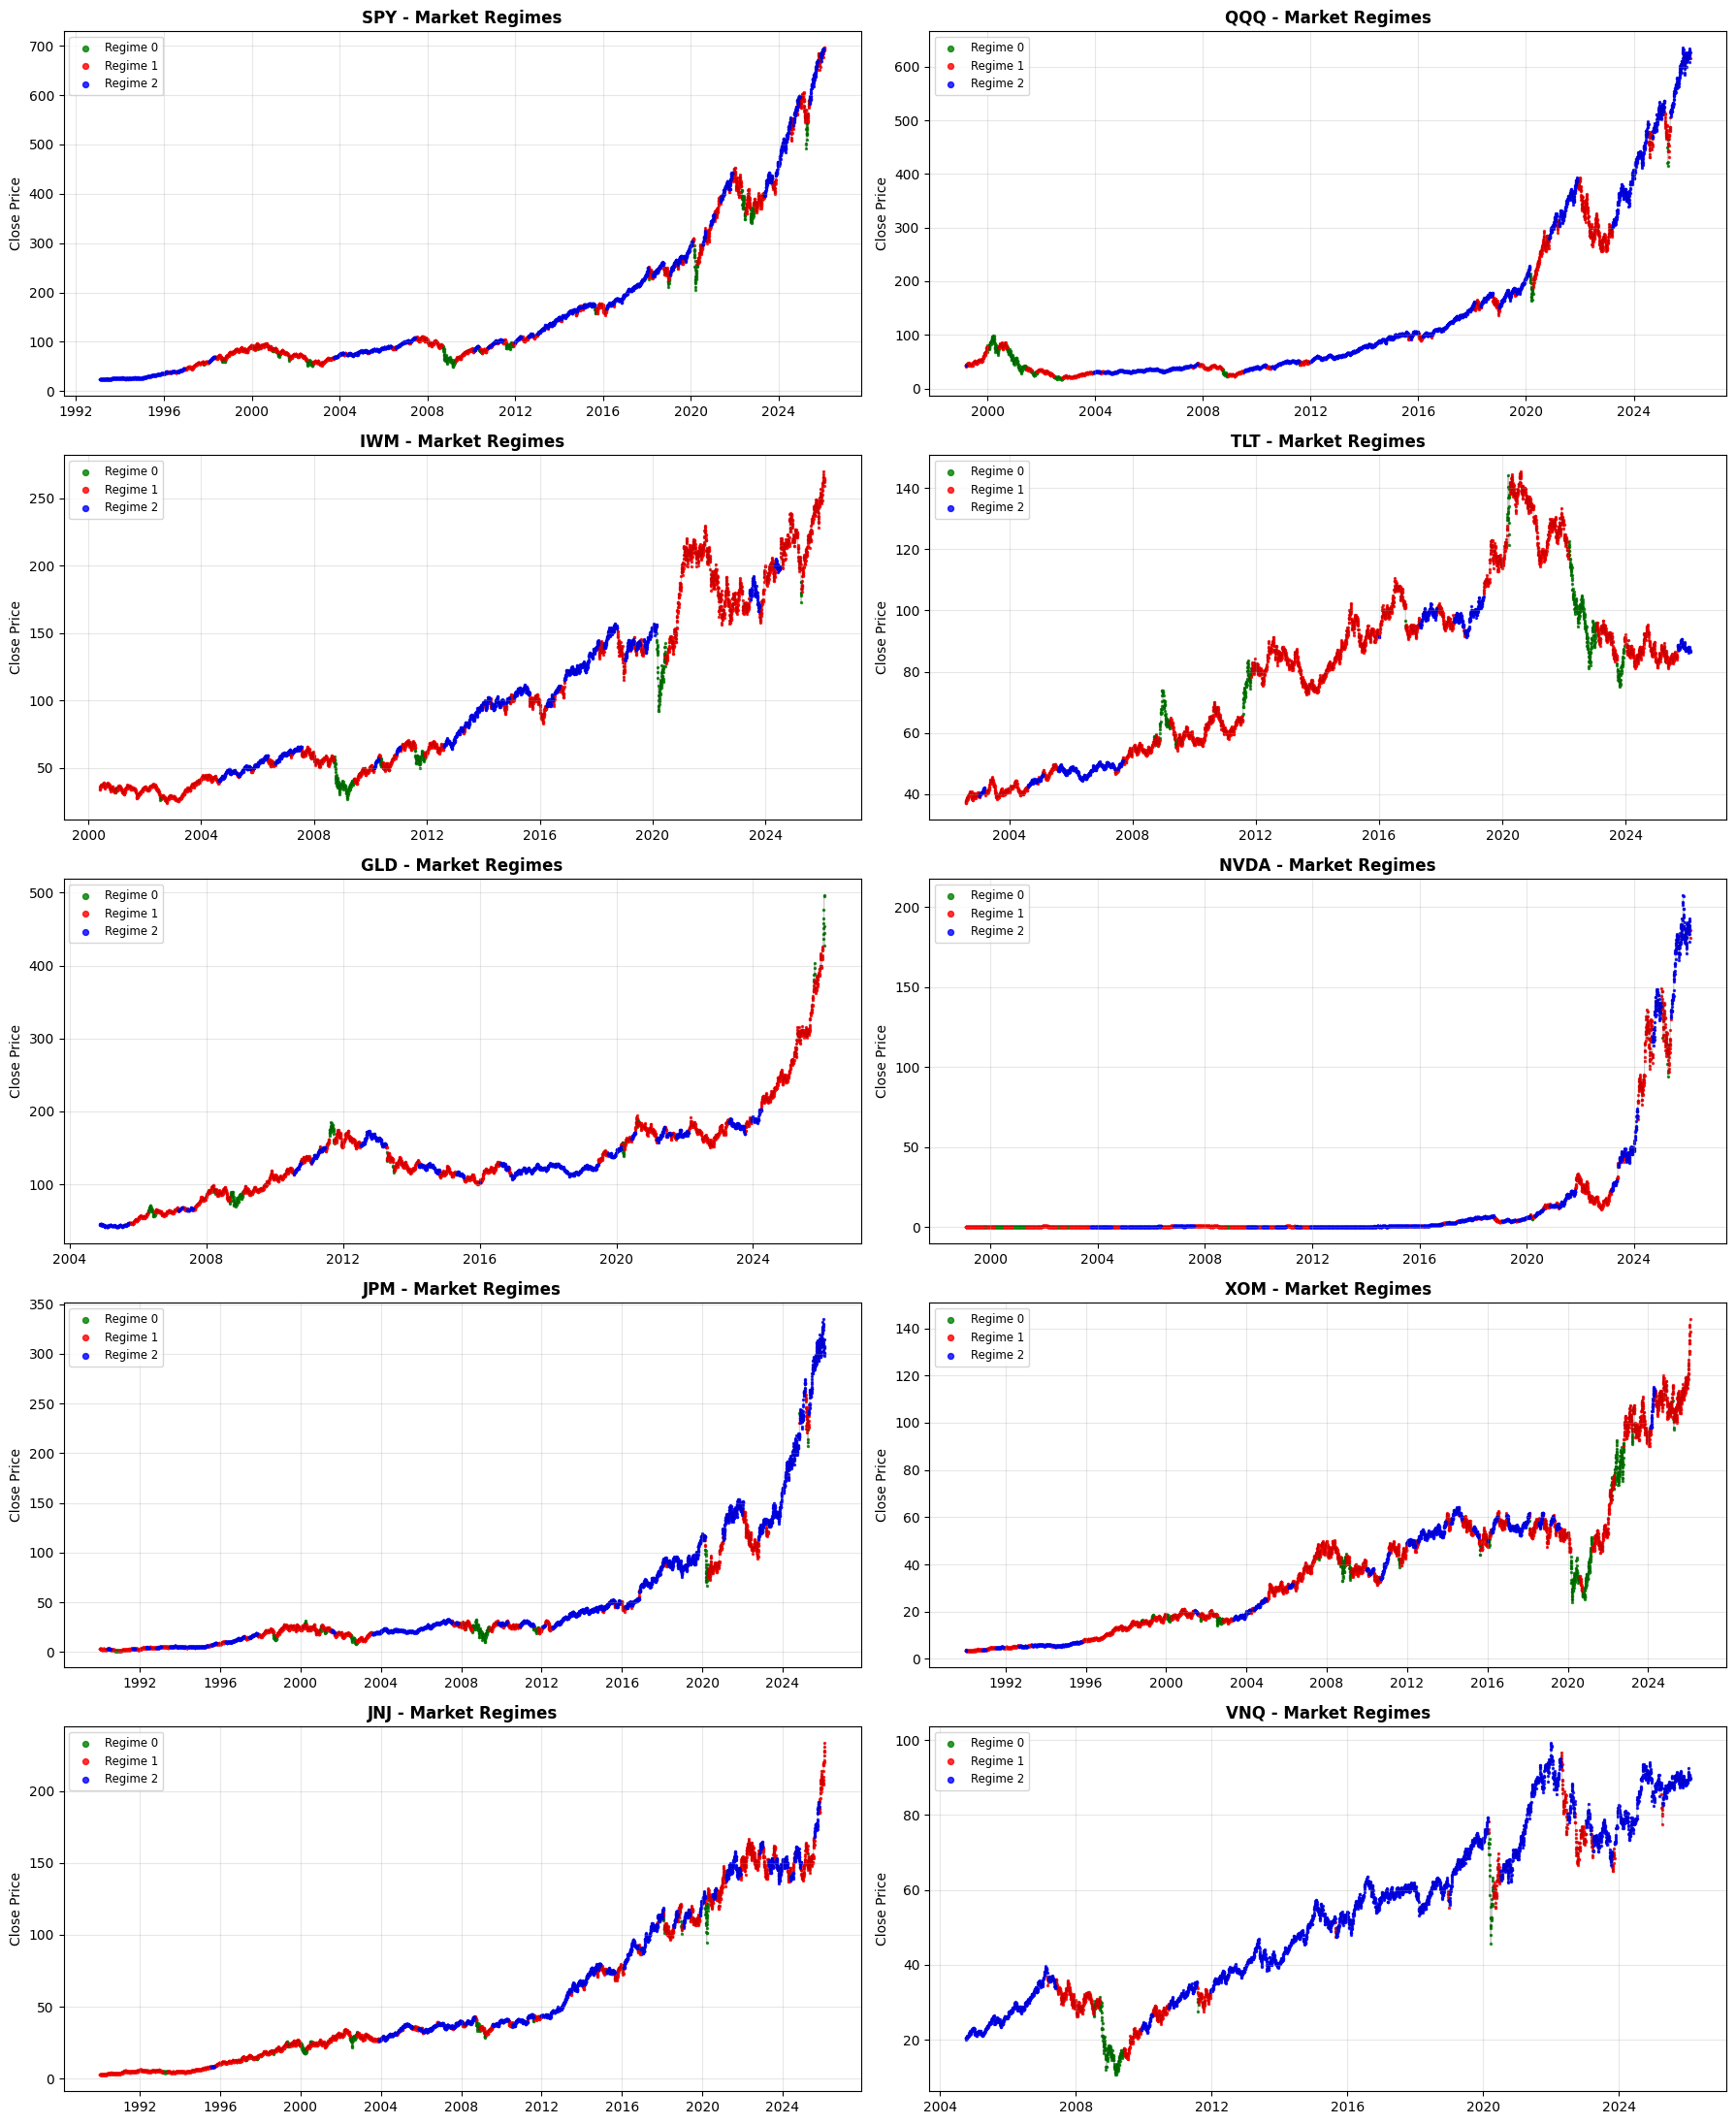

In [26]:
import matplotlib.pyplot as plt


tickers = [
    "SPY",   
    "QQQ",   
    "IWM",   
    "TLT",   
    "GLD",   
    "NVDA",  
    "JPM",   
    "XOM",   
    "JNJ",   
    "VNQ"    
]

fig, axes = plt.subplots(5, 2, figsize=(18, 22)) 
axes = axes.flatten() 

colors = ['green', 'red', 'blue']
regime_names = ['Regime 0', 'Regime 1', 'Regime 2']

print("Plotting regimes for all tickers...")

for idx, ticker in enumerate(tickers):
    if ticker not in combined_data['Symbol'].unique():
        print(f"Warning: {ticker} not found in combined_data. Skipping...")
        axes[idx].set_title(f'{ticker} - No Data Available')
        continue

    ax = axes[idx]
    
    ticker_data = combined_data[combined_data['Symbol'] == ticker].copy()
    ticker_data = ticker_data.set_index('Date')
    
    # Vẽ đường giá mờ làm nền
    ax.plot(ticker_data.index, ticker_data['Close'], linewidth=0.8, color='black', alpha=0.2)
    
    # Vẽ các điểm Regime
    for i in range(n_regimes):
        mask = ticker_data['Regime'] == i
        if mask.sum() > 0: # Chỉ vẽ nếu có dữ liệu của regime đó
            ax.scatter(ticker_data.index[mask], ticker_data['Close'][mask],
                       c=colors[i], s=2, alpha=0.8, label=regime_names[i])
    
    ax.set_ylabel('Close Price')
    ax.set_title(f'{ticker} - Market Regimes', fontweight='bold')
    ax.legend(loc='upper left', fontsize='small', markerscale=3)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Feature Engineering - Technical Indicators

In [27]:
df = combined_data.copy()
df = df.sort_values(['Symbol', 'Date'])

print("\nNaN count by column:")
print(df.isnull().sum())
print("\nNaN in Capital Gains by ticker:")
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker]
    nan_count = ticker_df['Capital Gains'].isnull().sum()
    print(f"  {ticker}: {nan_count}/{len(ticker_df)} NaN ({nan_count/len(ticker_df)*100:.1f}%)")

print("\n" + "="*60)
print("DROPPING 'Capital Gains' COLUMN")
print("="*60)
df = df.drop('Capital Gains', axis=1)

print("="*60)
print("BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

all_ticker_dfs = []
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker].copy()
    ticker_df = ticker_df.set_index('Date')
    
    # Trend Indicators
    ticker_df['SMA_10'] = ta.sma(ticker_df['Close'], length=10)
    ticker_df['SMA_50'] = ta.sma(ticker_df['Close'], length=50)
    ticker_df['EMA_12'] = ta.ema(ticker_df['Close'], length=12)
    ticker_df['EMA_26'] = ta.ema(ticker_df['Close'], length=26)
    
    # Momentum Indicators
    ticker_df['RSI'] = ta.rsi(ticker_df['Close'], length=14)
    macd = ta.macd(ticker_df['Close'])
    ticker_df['MACD'] = macd['MACD_12_26_9']
    ticker_df['MACD_signal'] = macd['MACDs_12_26_9']
    ticker_df['MACD_hist'] = macd['MACDh_12_26_9']
    
    # Volatility Indicators
    bbands = ta.bbands(ticker_df['Close'], length=20)
    if bbands is not None:
        bb_cols = bbands.columns.tolist()
        ticker_df['BB_upper'] = bbands[bb_cols[0]]
        ticker_df['BB_middle'] = bbands[bb_cols[1]]
        ticker_df['BB_lower'] = bbands[bb_cols[2]]
        ticker_df['BB_width'] = (ticker_df['BB_upper'] - ticker_df['BB_lower']) / ticker_df['BB_middle']
    
    ticker_df['ATR'] = ta.atr(ticker_df['High'], ticker_df['Low'], ticker_df['Close'], length=14)
    
    # Volume Indicators
    ticker_df['Volume_SMA'] = ta.sma(ticker_df['Volume'], length=20)
    ticker_df['Volume_ratio'] = ticker_df['Volume'] / ticker_df['Volume_SMA']
    
    # Price-based features
    ticker_df['Price_change_1d'] = ticker_df['Close'].pct_change(1)
    ticker_df['Price_change_5d'] = ticker_df['Close'].pct_change(5)
    ticker_df['Price_change_20d'] = ticker_df['Close'].pct_change(20)
    ticker_df['Volatility_20d'] = ticker_df['Returns'].rolling(window=20).std()
    
    # Distance from moving averages
    ticker_df['Dist_SMA10'] = (ticker_df['Close'] - ticker_df['SMA_10']) / ticker_df['SMA_10']
    ticker_df['Dist_SMA50'] = (ticker_df['Close'] - ticker_df['SMA_50']) / ticker_df['SMA_50']
    ticker_df['Dist_EMA12'] = (ticker_df['Close'] - ticker_df['EMA_12']) / ticker_df['EMA_12']
    
    # Position within Bollinger Bands
    ticker_df['BB_position'] = (ticker_df['Close'] - ticker_df['BB_lower']) / (ticker_df['BB_upper'] - ticker_df['BB_lower'])
    
    # Lag features
    for lag in [1, 2, 3, 5]:
        ticker_df[f'Return_lag_{lag}'] = ticker_df['Returns'].shift(lag)
    
    ticker_df = ticker_df.reset_index()
    
    print(f"\n{ticker} - BEFORE dropna: {len(ticker_df)} rows")
    ticker_df = ticker_df.dropna()
    print(f"{ticker} - AFTER dropna: {len(ticker_df)} rows (lost {len(df[df['Symbol'] == ticker]) - len(ticker_df)} rows)")
    
    all_ticker_dfs.append(ticker_df)

df = pd.concat(all_ticker_dfs, ignore_index=True)

print("\n" + "="*60)
print("BƯỚC 2: SAU KHI TÍNH FEATURES VÀ DROPNA")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"\nFeatures created: {df.shape[1]} columns")
print(f"Data points: {df.shape[0]} rows")
print(f"\nFeature columns:")
print([col for col in df.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol']])


NaN count by column:
Date                        0
Open                        0
High                        0
Low                         0
Close                       0
Volume                      0
Capital Gains           34063
Symbol                      0
Returns                     0
Returns_Standardized        0
Regime                      0
Regime_Prob_0               0
Regime_Prob_1               0
Regime_Prob_2               0
dtype: int64

NaN in Capital Gains by ticker:
  SPY: 0/8309 NaN (0.0%)
  QQQ: 0/6767 NaN (0.0%)
  IWM: 0/6459 NaN (0.0%)
  TLT: 0/5916 NaN (0.0%)
  GLD: 0/5334 NaN (0.0%)
  NVDA: 6799/6799 NaN (100.0%)
  JPM: 9088/9088 NaN (100.0%)
  XOM: 9088/9088 NaN (100.0%)
  JNJ: 9088/9088 NaN (100.0%)
  VNQ: 0/5370 NaN (0.0%)

DROPPING 'Capital Gains' COLUMN
BƯỚC 1: DỮ LIỆU SAU KHI HMM (BEFORE FEATURE ENGINEERING)
Total rows: 72218
  SPY: 8309 rows
  QQQ: 6767 rows
  IWM: 6459 rows
  TLT: 5916 rows
  GLD: 5334 rows
  NVDA: 6799 rows
  JPM: 9088 rows
  XOM: 9088 r

## Step 3: Create Target Variable (10-Day Prediction)


In [28]:
print("="*60)
print("TARGET (10-DAY FORWARD)")
print("="*60)
print(f"Before creating target: {len(df)} rows")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

df = df.sort_values(['Symbol', 'Date'])

all_target_dfs = []
for ticker in tickers:
    ticker_df = df[df['Symbol'] == ticker].copy()
    
    print(f"\n{ticker}:")
    print(f"  Before shift: {len(ticker_df)} rows")
    
    ticker_df['Return_10d_forward'] = ticker_df['Close'].pct_change(10).shift(-10)
    ticker_df['Target'] = (ticker_df['Return_10d_forward'] > 0).astype(int)
    
    print(f"  After shift (before removing last 10): {len(ticker_df)} rows")
    
    ticker_df = ticker_df[:-10]
    
    print(f"  After removing last 10 rows: {len(ticker_df)} rows")
    
    all_target_dfs.append(ticker_df)

df = pd.concat(all_target_dfs, ignore_index=True)

print("\n" + "="*60)
print("TARGET DISTRIBUTION (10-DAY PREDICTION - ALL TICKERS)")
print("="*60)
print(f"Total rows: {len(df)}")
for ticker in tickers:
    ticker_count = len(df[df['Symbol'] == ticker])
    print(f"  {ticker}: {ticker_count} rows")

print(f"\n{df['Target'].value_counts()}")
print(f"\nClass 1 (Up): {df['Target'].sum()} periods ({df['Target'].mean()*100:.2f}%)")
print(f"Class 0 (Down): {(1-df['Target']).sum()} periods ({(1-df['Target'].mean())*100:.2f}%)")

print("\n" + "="*60)
print("10-DAY TARGET DISTRIBUTION BY REGIME")
print("="*60)
for i in range(n_regimes):
    regime_data = df[df['Regime'] == i]
    up_pct = regime_data['Target'].mean() * 100
    print(f"Regime {i}: {up_pct:.2f}% up periods (10-day forward)")

TARGET (10-DAY FORWARD)
Before creating target: 71728 rows
  SPY: 8260 rows
  QQQ: 6718 rows
  IWM: 6410 rows
  TLT: 5867 rows
  GLD: 5285 rows
  NVDA: 6750 rows
  JPM: 9039 rows
  XOM: 9039 rows
  JNJ: 9039 rows
  VNQ: 5321 rows

SPY:
  Before shift: 8260 rows
  After shift (before removing last 10): 8260 rows
  After removing last 10 rows: 8250 rows

QQQ:
  Before shift: 6718 rows
  After shift (before removing last 10): 6718 rows
  After removing last 10 rows: 6708 rows

IWM:
  Before shift: 6410 rows
  After shift (before removing last 10): 6410 rows
  After removing last 10 rows: 6400 rows

TLT:
  Before shift: 5867 rows
  After shift (before removing last 10): 5867 rows
  After removing last 10 rows: 5857 rows

GLD:
  Before shift: 5285 rows
  After shift (before removing last 10): 5285 rows
  After removing last 10 rows: 5275 rows

NVDA:
  Before shift: 6750 rows
  After shift (before removing last 10): 6750 rows
  After removing last 10 rows: 6740 rows

JPM:
  Before shift: 903

## Step 4: Prepare Training Data with Regime Features

In [29]:
feature_columns = [
    # Momentum
    'RSI', 'MACD', 'MACD_hist',
    # Volatility
    'BB_width', 'ATR', 'Volatility_20d',
    # Volume
    # 'Volume_ratio',
    # Price changes
    # 'Price_change_5d', 
    'Price_change_20d',
    # Distance from moving averages (NEW)
    'Dist_SMA10', 'Dist_SMA50', 
    # 'Dist_EMA12',
    # Bollinger Band position (NEW)
    # 'BB_position',
    # Regime features
    'Regime', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2'
]

X = df[feature_columns].copy()
y = df['Target'].copy()
dates = df['Date'].copy()

print("="*60)
print("FEATURE MATRIX (ALL 6 TICKERS)")
print("="*60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

split_date = '2016-01-01'
train_mask = df['Date'] < split_date
test_mask = df['Date'] >= split_date

X_train, X_test = X[train_mask].reset_index(drop=True), X[test_mask].reset_index(drop=True)
y_train, y_test = y[train_mask].reset_index(drop=True), y[test_mask].reset_index(drop=True)
train_dates = dates[train_mask].reset_index(drop=True)
test_dates = dates[test_mask].reset_index(drop=True)
train_symbols = df[train_mask]['Symbol'].reset_index(drop=True)
test_symbols = df[test_mask]['Symbol'].reset_index(drop=True)

print("\n" + "="*60)
print("TRAIN/TEST SPLIT (ALL 6 TICKERS COMBINED)")
print("="*60)
print(f"Train: {train_dates.min()} to {train_dates.max()} ({len(X_train)} samples)")
print(f"Test: {test_dates.min()} to {test_dates.max()} ({len(X_test)} samples)")
print(f"\nTrain positive class: {y_train.mean()*100:.2f}%")
print(f"Test positive class: {y_test.mean()*100:.2f}%")

FEATURE MATRIX (ALL 6 TICKERS)
X shape: (71628, 13)
y shape: (71628,)

Features used (13):
   1. RSI
   2. MACD
   3. MACD_hist
   4. BB_width
   5. ATR
   6. Volatility_20d
   7. Price_change_20d
   8. Dist_SMA10
   9. Dist_SMA50
  10. Regime
  11. Regime_Prob_0
  12. Regime_Prob_1
  13. Regime_Prob_2

TRAIN/TEST SPLIT (ALL 6 TICKERS COMBINED)
Train: 1990-03-14 00:00:00-05:00 to 2015-12-31 00:00:00-05:00 (46368 samples)
Test: 2016-01-04 00:00:00-05:00 to 2026-01-20 00:00:00-05:00 (25260 samples)

Train positive class: 56.42%
Test positive class: 58.82%


## Step 5: Train ARIMAX Model (Thay thế LSTM)

**ARIMAX (AutoRegressive Integrated Moving Average with eXogenous variables)**
- **AR (p)**: Sử dụng giá trị quá khứ của chuỗi
- **I (d)**: Số lần difference để làm chuỗi dừng (stationary)
- **MA (q)**: Sử dụng các sai số dự đoán trong quá khứ
- **X**: Các biến ngoại sinh (technical indicators, regime features)

**Chiến lược:**
1. Dự đoán return 10 ngày tới cho từng ticker
2. Sử dụng features từ HMM & technical indicators làm biến ngoại sinh
3. Chuyển đổi dự đoán return thành tín hiệu Up/Down

In [30]:
# ===== ARIMAX MODEL TRAINING =====
# Chú thích: Thay thế LSTM bằng ARIMAX để dự đoán return 10 ngày tới

print("="*80)
print("ARIMAX MODEL - REGIME-BASED STOCK PREDICTION")
print("="*80)

# ----- Cấu hình ARIMAX -----
# p, d, q: Tham số ARIMAX (sẽ được tối ưu hóa theo từng ticker)
# Dùng order thấp để tránh overfitting: (1,0,1) hoặc (2,0,2)
DEFAULT_ORDER = (1, 0, 1)  # AR=1, Integrated=0, MA=1

# ----- Chọn Features làm biến ngoại sinh (exogenous variables) -----
exog_features = [
    'RSI', 'MACD', 'MACD_hist',  # Momentum
    'BB_width', 'ATR', 'Volatility_20d',  # Volatility
    'Price_change_20d',  # Price trend
    'Dist_SMA10', 'Dist_SMA50',  # Distance from MAs
    'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2'  # Regime probabilities
]

print(f"\nExogenous features ({len(exog_features)}): {exog_features}")

# ----- Chuẩn bị dữ liệu cho từng ticker -----
# ARIMAX yêu cầu train riêng cho từng ticker (không merge như LSTM)

ticker_models = {}  # Lưu model cho từng ticker
ticker_predictions = {}  # Lưu kết quả dự đoán

split_date = '2016-01-01'

for ticker in tickers:
    print("\n" + "="*80)
    print(f"TRAINING ARIMAX FOR {ticker}")
    print("="*80)
    
    # --- Lọc dữ liệu ticker ---
    ticker_df = df[df['Symbol'] == ticker].copy()
    ticker_df = ticker_df.sort_values('Date').reset_index(drop=True)
    
    # --- Split train/test ---
    train_mask = ticker_df['Date'] < split_date
    test_mask = ticker_df['Date'] >= split_date
    
    train_data = ticker_df[train_mask].copy()
    test_data = ticker_df[test_mask].copy()
    
    print(f"Train: {train_data['Date'].min().date()} to {train_data['Date'].max().date()} ({len(train_data)} samples)")
    print(f"Test:  {test_data['Date'].min().date()} to {test_data['Date'].max().date()} ({len(test_data)} samples)")
    
    # --- Chuẩn bị biến mục tiêu (y) và biến ngoại sinh (exog) ---
    # Target: Return_10d_forward (return thực tế 10 ngày sau)
    y_train = train_data['Return_10d_forward'].values
    y_test = test_data['Return_10d_forward'].values
    
    # Exogenous variables: Technical indicators + Regime features
    X_train_exog = train_data[exog_features].values
    X_test_exog = test_data[exog_features].values
    
    # --- Chuẩn hóa exog features (quan trọng cho ARIMAX) ---
    scaler = RobustScaler()
    X_train_exog_scaled = scaler.fit_transform(X_train_exog)
    X_test_exog_scaled = scaler.transform(X_test_exog)
    
    # --- Kiểm tra tính dừng (Stationarity) bằng ADF test ---
    # Nếu p-value < 0.05 => chuỗi dừng, không cần differencing (d=0)
    adf_result = adfuller(y_train)
    print(f"\nADF Test for stationarity:")
    print(f"  ADF Statistic: {adf_result[0]:.4f}")
    print(f"  p-value: {adf_result[1]:.4f}")
    
    if adf_result[1] > 0.05:
        print("  => Chuỗi KHÔNG dừng, nên dùng d=1 (differencing)")
        order = (1, 1, 1)  # Thêm differencing
    else:
        print("  => Chuỗi ĐÃ dừng, dùng d=0")
        order = DEFAULT_ORDER
    
    # --- Train ARIMAX ---
    print(f"\nTraining ARIMAX{order} with {len(exog_features)} exogenous variables...")
    
    try:
        # Fit ARIMAX model
        model = SARIMAX(
            y_train,
            exog=X_train_exog_scaled,
            order=order,
            enforce_stationarity=False,  # Cho phép linh hoạt hơn
            enforce_invertibility=False
        )
        
        model_fit = model.fit(disp=False, maxiter=200)
        
        # --- Dự đoán trên Test Set ---
        # ARIMAX cần exog cho cả quá trình dự đoán
        predictions = model_fit.forecast(steps=len(y_test), exog=X_test_exog_scaled)
        
        # --- Đánh giá hiệu suất (Regression metrics) ---
        mse = mean_squared_error(y_test, predictions)
        mae = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mse)
        
        print(f"\nRegression Performance:")
        print(f"  RMSE: {rmse:.6f}")
        print(f"  MAE:  {mae:.6f}")
        
        # --- Chuyển đổi sang Classification (Up/Down) ---
        # Thực tế: y_test > 0 => Up, ngược lại => Down
        y_test_class = (y_test > 0).astype(int)
        y_pred_class = (predictions > 0).astype(int)
        
        # Metrics
        acc = accuracy_score(y_test_class, y_pred_class)
        prec = precision_score(y_test_class, y_pred_class, average='weighted', zero_division=0)
        f1 = f1_score(y_test_class, y_pred_class, average='weighted')
        
        try:
            down_recall = recall_score(y_test_class, y_pred_class, pos_label=0, zero_division=0)
        except:
            down_recall = 0.0
        
        print(f"\nClassification Performance:")
        print(f"  Accuracy:     {acc:.4f}")
        print(f"  Precision:    {prec:.4f}")
        print(f"  F1-Score:     {f1:.4f}")
        print(f"  Down Recall:  {down_recall:.4f}")
        
        # --- Lưu model và kết quả ---
        ticker_models[ticker] = model_fit
        ticker_predictions[ticker] = {
            'y_true': y_test,
            'y_pred': predictions,
            'y_true_class': y_test_class,
            'y_pred_class': y_pred_class,
            'dates': test_data['Date'].values,
            'metrics': {
                'rmse': rmse,
                'mae': mae,
                'accuracy': acc,
                'precision': prec,
                'f1': f1,
                'down_recall': down_recall
            }
        }
        
    except Exception as e:
        print(f"ERROR training ARIMAX for {ticker}: {str(e)}")
        ticker_predictions[ticker] = None

# ----- Tổng hợp kết quả toàn bộ Tickers -----
print("\n" + "="*80)
print("OVERALL ARIMAX PERFORMANCE SUMMARY")
print("="*80)

results_summary = []
for ticker in tickers:
    if ticker_predictions[ticker] is not None:
        m = ticker_predictions[ticker]['metrics']
        results_summary.append({
            'Ticker': ticker,
            'Accuracy': m['accuracy'],
            'Precision': m['precision'],
            'F1-Score': m['f1'],
            'Down Recall': m['down_recall'],
            'RMSE': m['rmse'],
            'MAE': m['mae']
        })

results_df = pd.DataFrame(results_summary)
print(results_df.to_string(index=False))

print("\n" + "-"*80)
print(f"Average Accuracy:     {results_df['Accuracy'].mean():.4f} ± {results_df['Accuracy'].std():.4f}")
print(f"Average Down Recall:  {results_df['Down Recall'].mean():.4f} ± {results_df['Down Recall'].std():.4f}")
print(f"Average RMSE:         {results_df['RMSE'].mean():.6f}")
print("="*80)

ARIMAX MODEL - REGIME-BASED STOCK PREDICTION

Exogenous features (12): ['RSI', 'MACD', 'MACD_hist', 'BB_width', 'ATR', 'Volatility_20d', 'Price_change_20d', 'Dist_SMA10', 'Dist_SMA50', 'Regime_Prob_0', 'Regime_Prob_1', 'Regime_Prob_2']

TRAINING ARIMAX FOR SPY
Train: 1993-04-13 to 2015-12-31 (5724 samples)
Test:  2016-01-04 to 2026-01-20 (2526 samples)

ADF Test for stationarity:
  ADF Statistic: -11.3707
  p-value: 0.0000
  => Chuỗi ĐÃ dừng, dùng d=0

Training ARIMAX(1, 0, 1) with 12 exogenous variables...

Regression Performance:
  RMSE: 0.037725
  MAE:  0.025428

Classification Performance:
  Accuracy:     0.5400
  Precision:    0.5459
  F1-Score:     0.5428
  Down Recall:  0.3345

TRAINING ARIMAX FOR QQQ
Train: 1999-05-20 to 2015-12-31 (4182 samples)
Test:  2016-01-04 to 2026-01-20 (2526 samples)

ADF Test for stationarity:
  ADF Statistic: -9.1498
  p-value: 0.0000
  => Chuỗi ĐÃ dừng, dùng d=0

Training ARIMAX(1, 0, 1) with 12 exogenous variables...

Regression Performance:
  RMSE

ARIMAX PREDICTIONS - VISUAL COMPARISON


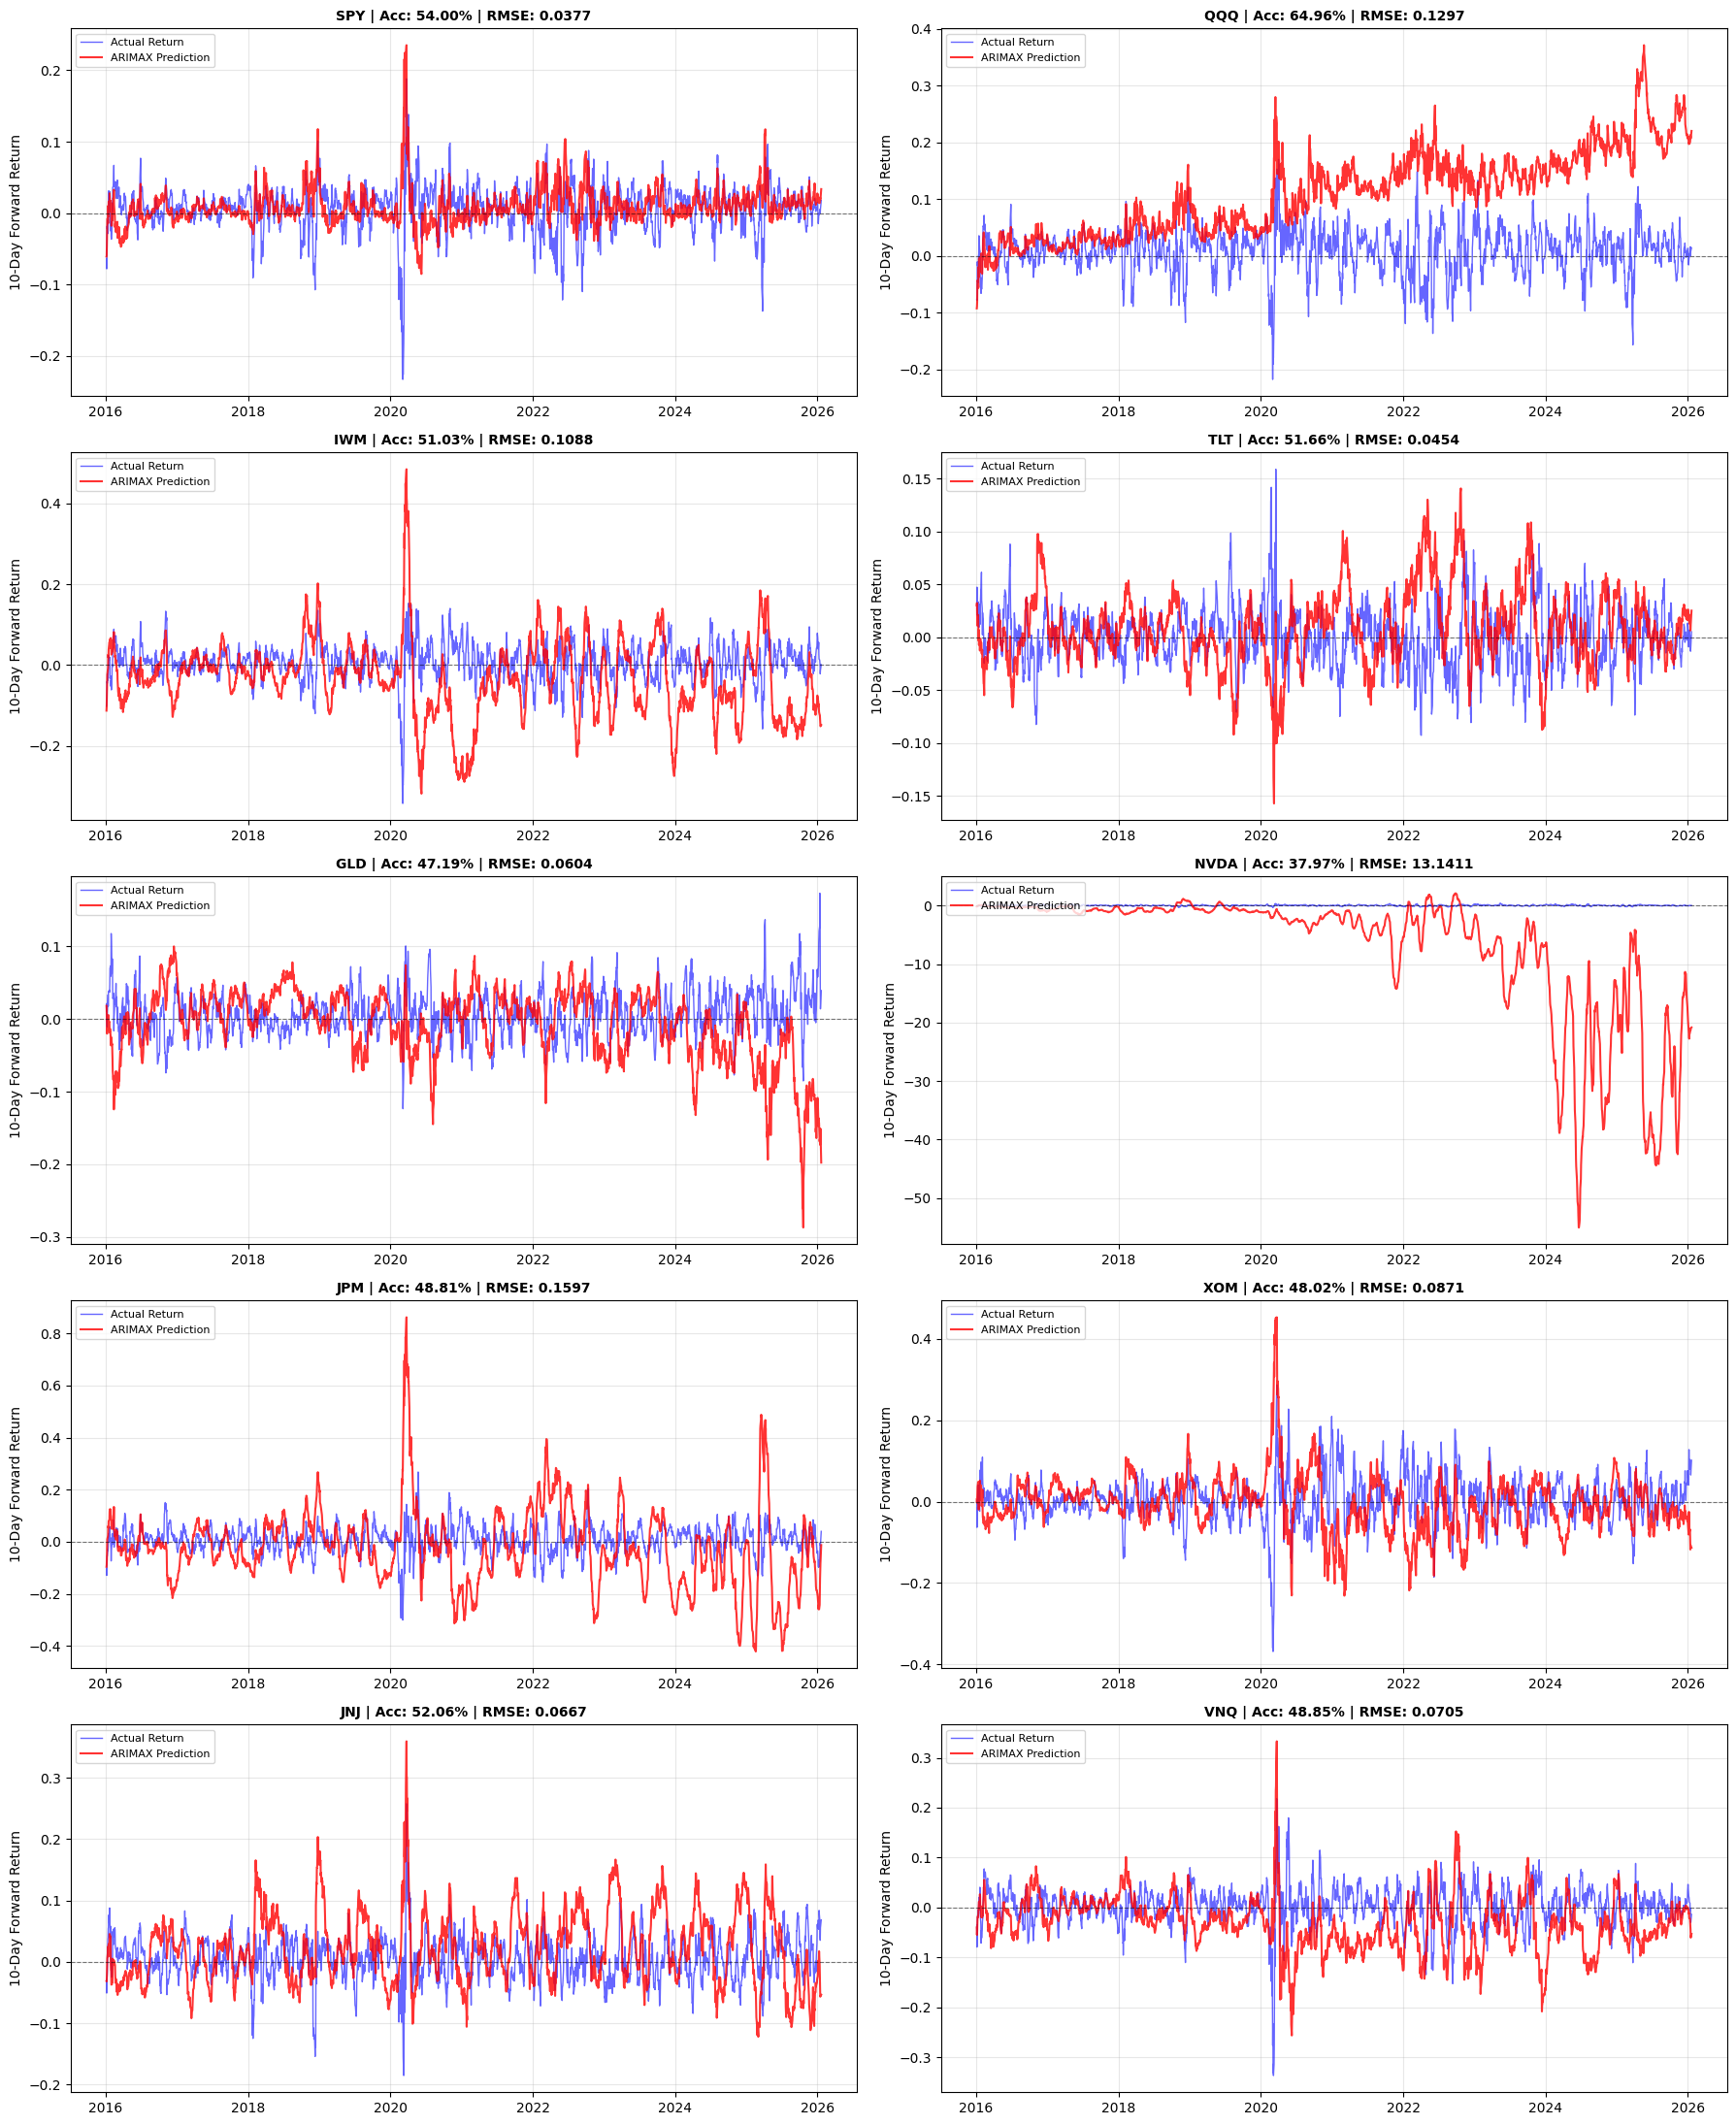


Summary Statistics:
Best Accuracy: 0.6496 (QQQ)
Worst Accuracy: 0.3797 (NVDA)
Best Down Recall: 0.9120 (NVDA)
Lowest RMSE: 0.037725 (SPY)


In [31]:
# ===== VISUALIZATION: ARIMAX PREDICTIONS VS ACTUAL =====
# Chú thích: Vẽ biểu đồ so sánh dự đoán ARIMAX vs thực tế cho từng ticker

print("="*60)
print("ARIMAX PREDICTIONS - VISUAL COMPARISON")
print("="*60)

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for idx, ticker in enumerate(tickers):
    ax = axes[idx]
    
    if ticker_predictions[ticker] is None:
        ax.set_title(f'{ticker} - Training Failed', fontweight='bold', color='red')
        ax.text(0.5, 0.5, 'Model training failed', ha='center', va='center', fontsize=12)
        continue
    
    pred_data = ticker_predictions[ticker]
    dates = pd.to_datetime(pred_data['dates'])
    y_true = pred_data['y_true']
    y_pred = pred_data['y_pred']
    
    # Plot actual vs predicted returns
    ax.plot(dates, y_true, label='Actual Return', color='blue', alpha=0.6, linewidth=1)
    ax.plot(dates, y_pred, label='ARIMAX Prediction', color='red', alpha=0.8, linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Metrics
    metrics = pred_data['metrics']
    ax.set_title(f"{ticker} | Acc: {metrics['accuracy']:.2%} | RMSE: {metrics['rmse']:.4f}", 
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('10-Day Forward Return')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----- Summary Statistics -----
print("\nSummary Statistics:")
print(f"Best Accuracy: {results_df['Accuracy'].max():.4f} ({results_df.loc[results_df['Accuracy'].idxmax(), 'Ticker']})")
print(f"Worst Accuracy: {results_df['Accuracy'].min():.4f} ({results_df.loc[results_df['Accuracy'].idxmin(), 'Ticker']})")
print(f"Best Down Recall: {results_df['Down Recall'].max():.4f} ({results_df.loc[results_df['Down Recall'].idxmax(), 'Ticker']})")
print(f"Lowest RMSE: {results_df['RMSE'].min():.6f} ({results_df.loc[results_df['RMSE'].idxmin(), 'Ticker']})")

OVERALL CONFUSION MATRIX - ALL TICKERS COMBINED


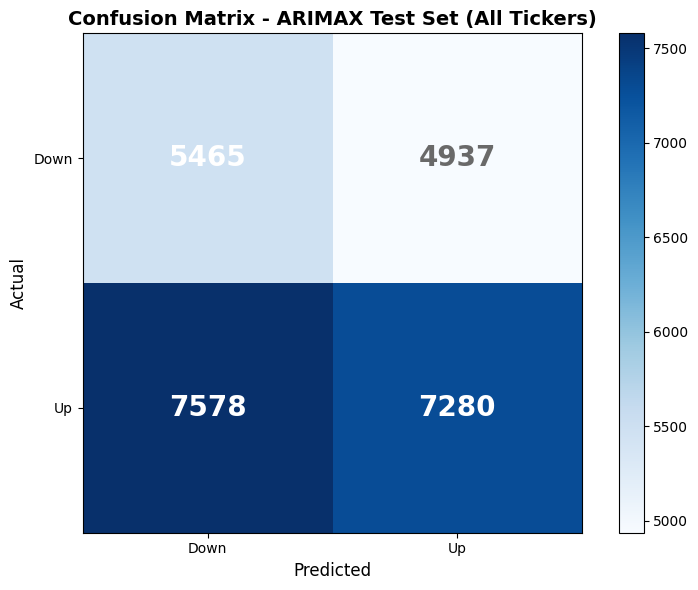


Detailed Metrics:
True Negatives:  5465
False Positives: 4937
False Negatives: 7578
True Positives:  7280

Overall Precision: 0.5959
Overall Recall:    0.4900
Overall Accuracy:  0.5046

------------------------------------------------------------
CLASSIFICATION REPORT - ALL TICKERS
------------------------------------------------------------
              precision    recall  f1-score   support

        Down       0.42      0.53      0.47     10402
          Up       0.60      0.49      0.54     14858

    accuracy                           0.50     25260
   macro avg       0.51      0.51      0.50     25260
weighted avg       0.52      0.50      0.51     25260



In [32]:
# ===== CONFUSION MATRIX - ARIMAX OVERALL =====
# Chú thích: Tổng hợp confusion matrix từ tất cả tickers

print("="*60)
print("OVERALL CONFUSION MATRIX - ALL TICKERS COMBINED")
print("="*60)

# Gộp tất cả predictions từ các tickers
all_y_true = []
all_y_pred = []

for ticker in tickers:
    if ticker_predictions[ticker] is not None:
        all_y_true.extend(ticker_predictions[ticker]['y_true_class'])
        all_y_pred.extend(ticker_predictions[ticker]['y_pred_class'])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Tạo confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred)

# Visualization với logic màu text được cải thiện
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

# Add labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Down', 'Up'])
ax.set_yticklabels(['Down', 'Up'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix - ARIMAX Test Set (All Tickers)', fontsize=14, fontweight='bold')

# Add text annotations với màu tùy chỉnh
threshold = cm.max() / 2.0

for i in range(2):
    for j in range(2):
        cell_value = cm[i, j]
        
        # Tùy chỉnh riêng cho False Positives (i=0, j=1)
        if i == 0 and j == 1:
            # False Positives: Dùng màu xám đậm để nổi bật trên nền xanh nhạt
            text_color = "dimgray"  # Màu xám đậm
        else:
            # Các ô khác: Logic bình thường
            text_color = "white" if cell_value > threshold else "black"
        
        ax.text(j, i, cm[i, j], 
                ha="center", va="center", 
                color=text_color,
                fontsize=20, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
print("\nDetailed Metrics:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nOverall Precision: {tp/(tp+fp):.4f}")
print(f"Overall Recall:    {tp/(tp+fn):.4f}")
print(f"Overall Accuracy:  {(tp+tn)/(tp+tn+fp+fn):.4f}")

print("\n" + "-"*60)
print("CLASSIFICATION REPORT - ALL TICKERS")
print("-"*60)
print(classification_report(all_y_true, all_y_pred, target_names=['Down', 'Up']))

In [33]:
# ===== SLIDING WINDOW VALIDATION - ARIMAX =====
# Chú thích: Walk-forward validation để kiểm tra tính ổn định của ARIMAX theo thời gian

print("="*80)
print("SLIDING WINDOW VALIDATION - ARIMAX")
print("="*80)

# ----- Cấu hình cửa sổ -----
train_window_years = 3
test_window_months = 6

train_window_days = train_window_years * 252  # ~252 ngày giao dịch/năm
test_window_days = test_window_months * 21    # ~21 ngày giao dịch/tháng

print(f"Configuration:")
print(f"  Train window: {train_window_years} years (~{train_window_days} trading days)")
print(f"  Test window:  {test_window_months} months (~{test_window_days} trading days)")
print(f"  ARIMAX order: {DEFAULT_ORDER}")

# ----- Chạy validation cho từng ticker -----
ticker_sw_results = {}

for ticker in tickers:
    print("\n" + "="*80)
    print(f"SLIDING WINDOW FOR {ticker}")
    print("="*80)
    
    # Lọc dữ liệu ticker
    ticker_df = df[df['Symbol'] == ticker].copy()
    ticker_df = ticker_df.sort_values('Date').reset_index(drop=True)
    
    # Chỉ lấy train data (trước 2016)
    ticker_train = ticker_df[ticker_df['Date'] < split_date].copy()
    
    # Tạo các cửa sổ
    sw_walks = []
    current_pos = train_window_days
    
    while current_pos + test_window_days <= len(ticker_train):
        sw_walks.append({
            'train_start': current_pos - train_window_days,
            'train_end': current_pos,
            'test_start': current_pos,
            'test_end': min(current_pos + test_window_days, len(ticker_train))
        })
        current_pos += test_window_days  # Cuộn theo test window
    
    if len(sw_walks) == 0:
        print(f"  Không đủ dữ liệu để tạo sliding window cho {ticker}")
        ticker_sw_results[ticker] = []
        continue
    
    print(f"  Generated {len(sw_walks)} windows")
    
    # ----- Chạy ARIMAX cho từng window -----
    window_results = []
    
    for i, walk in enumerate(sw_walks, 1):
        # Chuẩn bị dữ liệu
        train_w = ticker_train.iloc[walk['train_start']:walk['train_end']]
        test_w = ticker_train.iloc[walk['test_start']:walk['test_end']]
        
        y_train_w = train_w['Return_10d_forward'].values
        y_test_w = test_w['Return_10d_forward'].values
        
        X_train_w = train_w[exog_features].values
        X_test_w = test_w[exog_features].values
        
        # Scale
        scaler_w = RobustScaler()
        X_train_w_scaled = scaler_w.fit_transform(X_train_w)
        X_test_w_scaled = scaler_w.transform(X_test_w)
        
        # Kiểm tra stationarity
        try:
            adf_res = adfuller(y_train_w)
            order_w = (1, 1, 1) if adf_res[1] > 0.05 else DEFAULT_ORDER
        except:
            order_w = DEFAULT_ORDER
        
        # Train ARIMAX
        try:
            mdl = SARIMAX(y_train_w, exog=X_train_w_scaled, order=order_w,
                         enforce_stationarity=False, enforce_invertibility=False)
            mdl_fit = mdl.fit(disp=False, maxiter=100)
            
            # Predict
            preds = mdl_fit.forecast(steps=len(y_test_w), exog=X_test_w_scaled)
            
            # Metrics
            rmse = np.sqrt(mean_squared_error(y_test_w, preds))
            mae = mean_absolute_error(y_test_w, preds)
            
            # Classification
            y_test_class = (y_test_w > 0).astype(int)
            y_pred_class = (preds > 0).astype(int)
            acc = accuracy_score(y_test_class, y_pred_class)
            
            try:
                down_recall = recall_score(y_test_class, y_pred_class, pos_label=0, zero_division=0)
            except:
                down_recall = 0.0
            
            window_results.append({
                'window': i,
                'test_period': f"{test_w['Date'].min().date()} -> {test_w['Date'].max().date()}",
                'accuracy': acc,
                'rmse': rmse,
                'mae': mae,
                'down_recall': down_recall
            })
            
            print(f"  Win {i}: {test_w['Date'].min().date()} -> {test_w['Date'].max().date()} | Acc: {acc:.4f} | RMSE: {rmse:.6f}")
            
        except Exception as e:
            print(f"  Win {i}: FAILED - {str(e)}")
            continue
    
    ticker_sw_results[ticker] = window_results

# ----- Tổng hợp kết quả -----
print("\n" + "="*80)
print("SLIDING WINDOW SUMMARY - ALL TICKERS")
print("="*80)

for ticker in tickers:
    if len(ticker_sw_results.get(ticker, [])) > 0:
        res_df = pd.DataFrame(ticker_sw_results[ticker])
        print(f"\n{ticker}:")
        print(f"  Total Windows: {len(res_df)}")
        print(f"  Avg Accuracy:  {res_df['accuracy'].mean():.4f} ± {res_df['accuracy'].std():.4f}")
        print(f"  Avg RMSE:      {res_df['rmse'].mean():.6f}")
        print(f"  Avg Down Recall: {res_df['down_recall'].mean():.4f}")

# Tổng hợp toàn bộ
all_sw_results = []
for ticker, results in ticker_sw_results.items():
    for r in results:
        r['ticker'] = ticker
        all_sw_results.append(r)

if len(all_sw_results) > 0:
    all_sw_df = pd.DataFrame(all_sw_results)
    print("\n" + "="*80)
    print("OVERALL SLIDING WINDOW PERFORMANCE")
    print("="*80)
    print(f"Total Windows (all tickers): {len(all_sw_df)}")
    print(f"Average Accuracy:    {all_sw_df['accuracy'].mean():.4f} ± {all_sw_df['accuracy'].std():.4f}")
    print(f"Average RMSE:        {all_sw_df['rmse'].mean():.6f}")
    print(f"Average Down Recall: {all_sw_df['down_recall'].mean():.4f}")
    print("="*80)
else:
    print("\nNo sliding window results available.")

SLIDING WINDOW VALIDATION - ARIMAX
Configuration:
  Train window: 3 years (~756 trading days)
  Test window:  6 months (~126 trading days)
  ARIMAX order: (1, 0, 1)

SLIDING WINDOW FOR SPY
  Generated 39 windows
  Win 1: 1996-04-09 -> 1996-10-04 | Acc: 0.5714 | RMSE: 0.028510
  Win 2: 1996-10-07 -> 1997-04-07 | Acc: 0.5000 | RMSE: 0.029677
  Win 3: 1997-04-08 -> 1997-10-03 | Acc: 0.4444 | RMSE: 0.054281
  Win 4: 1997-10-06 -> 1998-04-06 | Acc: 0.5238 | RMSE: 0.075875
  Win 5: 1998-04-07 -> 1998-10-05 | Acc: 0.5159 | RMSE: 0.057424
  Win 6: 1998-10-06 -> 1999-04-07 | Acc: 0.4841 | RMSE: 0.046332
  Win 7: 1999-04-08 -> 1999-10-05 | Acc: 0.5794 | RMSE: 0.041612
  Win 8: 1999-10-06 -> 2000-04-04 | Acc: 0.5952 | RMSE: 0.045549
  Win 9: 2000-04-05 -> 2000-10-03 | Acc: 0.5873 | RMSE: 0.037971
  Win 10: 2000-10-04 -> 2001-04-04 | Acc: 0.4524 | RMSE: 0.065191
  Win 11: 2001-04-05 -> 2001-10-09 | Acc: 0.5556 | RMSE: 0.052817
  Win 12: 2001-10-10 -> 2002-04-11 | Acc: 0.5794 | RMSE: 0.038571
  Win